<a href="https://colab.research.google.com/github/emersonprates/Notebooks/blob/main/ProjetoPos2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import GridSearchCV
import xgboost as xgb
import lightgbm as lgb

In [ ]:
DATA_PATH = Path('Dados Históricos - Ibovespa.csv')
TEST_DAYS = 30
RANDOM_STATE = 42

In [ ]:
def load_and_clean(path):
    df_raw = pd.read_csv(path, sep=',', encoding='utf-8', engine='python')
    if len(df_raw.columns) == 1:
        df = df_raw.iloc[:,0].str.split(',', expand=True)
        df.columns = ['Data', 'Último', 'Abertura', 'Máxima', 'Mínima', 'Vol', 'Var%']
    else:
        df = df_raw.copy()
        if len(df.columns) >= 7:
            df = df.iloc[:, :7]
            df.columns = ['Data', 'Último', 'Abertura', 'Máxima', 'Mínima', 'Vol', 'Var%']

    df['Data'] = pd.to_datetime(df['Data'], format='%d.%m.%Y', errors='coerce')

    def clean_num(col):
        return (col.astype(str)
                .str.replace('"', '', regex=False)
                .str.replace('.', '', regex=False)
                .str.replace(',', '.', regex=False)
                .replace({'nan': np.nan, 'None': np.nan})
                .astype(float))

    for c in ['Último', 'Abertura', 'Máxima', 'Mínima']:
        df[c] = clean_num(df[c])

    df = df.sort_values('Data').reset_index(drop=True)
    return df

df = load_and_clean(DATA_PATH)
print('Linhas após leitura:', len(df))
df.head()

Linhas após leitura: 1000


,Data,Último,Abertura,Máxima,Mínima,Vol,Var%
0,2021-10-22,106296.0,107714.0,107749.0,102854.0,"21,17M","-1,34%"
1,2021-10-25,108715.0,106298.0,109372.0,106296.0,"11,51M","2,28%"
2,2021-10-26,10642.0,108713.0,108713.0,106321.0,"10,76M","-2,11%"
3,2021-10-27,106363.0,106433.0,108224.0,106045.0,"10,83M","-0,05%"
4,2021-10-28,105705.0,106369.0,10721.0,105282.0,"11,50M","-0,62%"


In [ ]:
df['Target'] = (df['Último'].shift(-1) > df['Último']).astype(int)
print('Distribuição do target:')
print(df['Target'].value_counts(dropna=False))

df[['Data','Último','Target']].tail()

Distribuição do target:
Target
1    505
0    495
Name: count, dtype: int64


,Data,Último,Target
995,2025-10-16,1422.0,1
996,2025-10-17,143399.0,1
997,2025-10-20,144509.0,0
998,2025-10-21,144085.0,1
999,2025-10-22,144873.0,0


In [ ]:
df['Return'] = df['Último'].pct_change()
df['Return_1'] = df['Return'].shift(1)
df['SMA_5'] = df['Último'].rolling(window=5).mean()
df['SMA_10'] = df['Último'].rolling(window=10).mean()
df['SMA_20'] = df['Último'].rolling(window=20).mean()
df['Volatility_10'] = df['Return'].rolling(window=10).std()
df['High_Low_Range'] = (df['Máxima'] - df['Mínima']) / df['Último']

model_df = df.dropna().reset_index(drop=True)
print('Linhas após engenharia de features e dropna:', len(model_df))
model_df.head()

Linhas após engenharia de features e dropna: 981


,Data,Último,Abertura,Máxima,Mínima,Vol,Var%,Target,Return,Return_1,SMA_5,SMA_10,SMA_20,Volatility_10,High_Low_Range
0,2021-11-22,102122.0,103036.0,104613.0,102122.0,"10,41M","-0,89%",1,-0.008861,0.005946,102987.0,104514.9,100288.75,0.010751,0.024392
1,2021-11-23,103654.0,102124.0,103841.0,101736.0,"13,03M","1,50%",1,0.015002,-0.008861,102837.0,104402.2,100156.65,0.012111,0.020308
2,2021-11-24,104514.0,103652.0,105041.0,102464.0,"10,47M","0,83%",1,0.008297,0.015002,103150.2,104300.1,99946.60,0.012199,0.024657
3,2021-11-25,105811.0,104514.0,1064.0,104514.0,"7,89M","1,24%",0,0.012410,0.008297,103827.2,104284.4,104705.05,0.012843,-0.977687
4,2021-11-26,102224.0,10581.0,10581.0,101495.0,"10,97M","-3,39%",1,-0.033900,0.012410,103665.0,103747.3,104498.10,0.015449,-0.889361


In [ ]:
if len(model_df) <= TEST_DAYS + 10:
    TEST_DAYS = int(len(model_df) * 0.2)

train = model_df.iloc[:-TEST_DAYS]
test = model_df.iloc[-TEST_DAYS:]

features = ['Return_1','SMA_5','SMA_10','SMA_20','Volatility_10','High_Low_Range']
X_train = train[features].values
y_train = train['Target'].values
X_test = test[features].values
y_test = test['Target'].values

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print('Tamanho treino:', X_train_s.shape, 'Tamanho teste:', X_test_s.shape)

Tamanho treino: (951, 6) Tamanho teste: (30, 6)


In [ ]:
clf = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
clf.fit(X_train_s, y_train)
y_pred = clf.predict(X_test_s)

print('Acurácia (teste):', round(accuracy_score(y_test, y_pred),4))
print('Matriz de confusão:\n', confusion_matrix(y_test, y_pred))
print('\nRelatório de classificação:\n', classification_report(y_test, y_pred, digits=4))

joblib.dump(clf, 'modelo_logistic.joblib')
joblib.dump(scaler, 'scaler.joblib')
print('\nModelos salvos: modelo_logistic.joblib, scaler.joblib')

Acurácia (teste): 0.5667
Matriz de confusão:
 [[15  0]
 [13  2]]

Relatório de classificação:
               precision    recall  f1-score   support

           0     0.5357    1.0000    0.6977        15
           1     1.0000    0.1333    0.2353        15

    accuracy                         0.5667        30
   macro avg     0.7679    0.5667    0.4665        30
weighted avg     0.7679    0.5667    0.4665        30


Modelos salvos: modelo_logistic.joblib, scaler.joblib


In [ ]:
rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
print('RF Acurácia (teste):', round(accuracy_score(y_test, rf_pred),4))
print('Matriz de confusão RF:\n', confusion_matrix(y_test, rf_pred))

joblib.dump(rf, 'modelo_rf.joblib')
print('Random Forest salvo: modelo_rf.joblib')

RF Acurácia (teste): 0.7
Matriz de confusão RF:
 [[12  3]
 [ 6  9]]
Random Forest salvo: modelo_rf.joblib


In [ ]:
display_cols = ['Data','Último'] + features + ['Target']
print(test[display_cols].tail(10))

          Data    Último   Return_1     SMA_5    SMA_10     SMA_20  \
971 2025-10-09  141708.0   0.005582  142603.6  131095.1  138056.10   
972 2025-10-10   14068.0  -0.003074  116577.0  117957.2  131645.90   
973 2025-10-13  141783.0  -0.900725  116212.0  117501.8  131557.70   
974 2025-10-14  141683.0   9.078405  116277.4  117046.4  131438.75   
975 2025-10-15  142604.0  -0.000705  116369.2  116755.1  131289.25   
976 2025-10-16    1422.0   0.006500   88312.0  115457.8  124085.40   
977 2025-10-17  143399.0  -0.990028  114178.2  115377.6  123962.10   
978 2025-10-20  144509.0  99.843179  114723.4  115467.7  123932.10   
979 2025-10-21  144085.0   0.007741  115203.8  115740.6  123815.10   
980 2025-10-22  144873.0  -0.002934  115657.6  116013.4  123734.15   

     Volatility_10  High_Low_Range  Target  
971       2.897596        0.011354       0  
972       2.939301        0.145223       1  
973       3.928247        0.011433       0  
974       3.928248        0.008858       1  
975 

In [ ]:
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=RANDOM_STATE)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.1]
}
grid_xgb = GridSearchCV(xgb_model, param_grid, cv=3, scoring='accuracy', verbose=1, n_jobs=-1)
grid_xgb.fit(X_train, y_train)

print("Melhores parâmetros XGBoost:", grid_xgb.best_params_)
xgb_best = grid_xgb.best_estimator_
xgb_pred = xgb_best.predict(X_test)
print("XGBoost Acurácia (teste):", round(accuracy_score(y_test, xgb_pred), 4))
print(confusion_matrix(y_test, xgb_pred))
print(classification_report(y_test, xgb_pred, digits=4))


Fitting 3 folds for each of 8 candidates, totalling 24 fits
Melhores parâmetros XGBoost: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100}
XGBoost Acurácia (teste): 0.7
[[14  1]
 [ 8  7]]
              precision    recall  f1-score   support

           0     0.6364    0.9333    0.7568        15
           1     0.8750    0.4667    0.6087        15

    accuracy                         0.7000        30
   macro avg     0.7557    0.7000    0.6827        30
weighted avg     0.7557    0.7000    0.6827        30



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [13:15:20] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
lgb_model = lgb.LGBMClassifier(random_state=RANDOM_STATE)
param_grid_lgb = {
    'n_estimators': [100, 200],
    'max_depth': [-1, 5],
    'learning_rate': [0.01, 0.1]
}
grid_lgb = GridSearchCV(lgb_model, param_grid_lgb, cv=3, scoring='accuracy', verbose=1, n_jobs=-1)
grid_lgb.fit(X_train, y_train)

print("Melhores parâmetros LightGBM:", grid_lgb.best_params_)
lgb_best = grid_lgb.best_estimator_
lgb_pred = lgb_best.predict(X_test)
print("LightGBM Acurácia (teste):", round(accuracy_score(y_test, lgb_pred), 4))
print(confusion_matrix(y_test, lgb_pred))
print(classification_report(y_test, lgb_pred, digits=4))


Fitting 3 folds for each of 8 candidates, totalling 24 fits
[LightGBM] [Info] Number of positive: 481, number of negative: 470
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000067 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 951, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.505783 -> initscore=0.023135
[LightGBM] [Info] Start training from score 0.023135
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warn

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


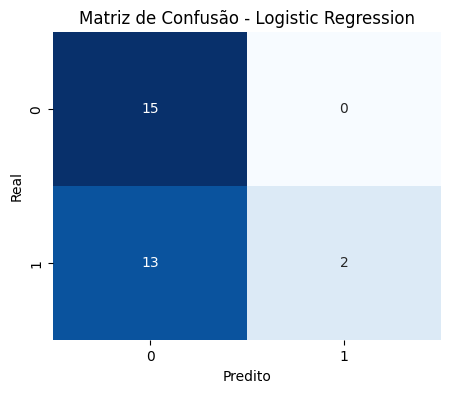

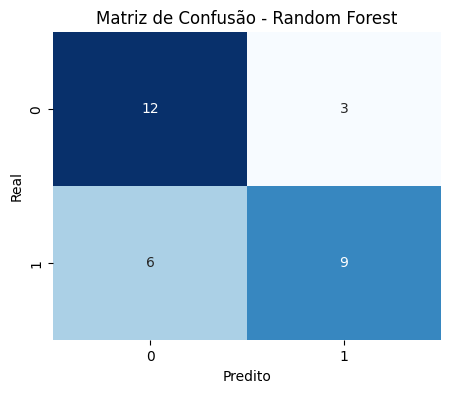

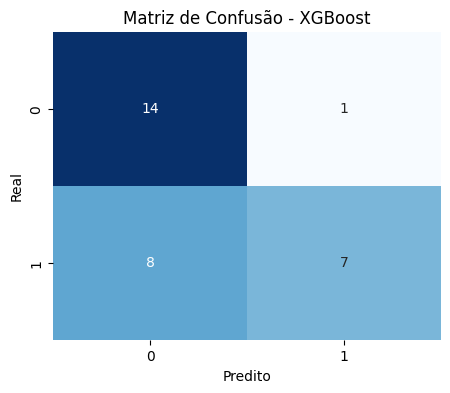

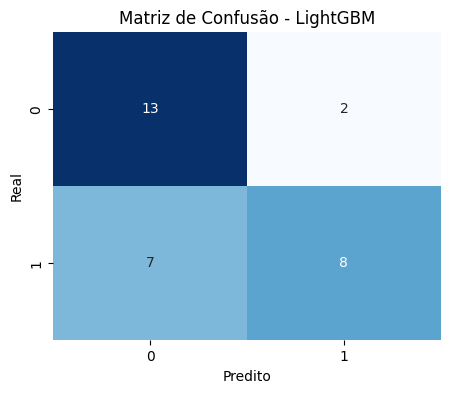

In [ ]:
def plot_conf_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(title)
    plt.xlabel("Predito")
    plt.ylabel("Real")
    plt.show()

plot_conf_matrix(y_test, y_pred, "Matriz de Confusão - Logistic Regression")
plot_conf_matrix(y_test, rf_pred, "Matriz de Confusão - Random Forest")
plot_conf_matrix(y_test, xgb_pred, "Matriz de Confusão - XGBoost")
plot_conf_matrix(y_test, lgb_pred, "Matriz de Confusão - LightGBM")


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


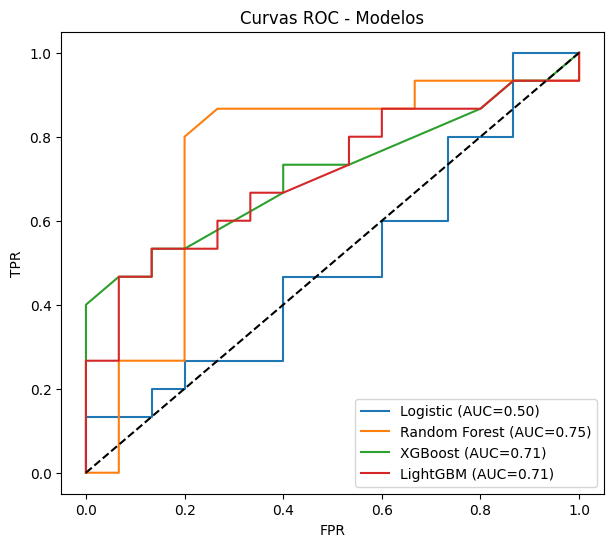

In [ ]:
plt.figure(figsize=(7,6))

def plot_roc(y_true, y_proba, label):
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{label} (AUC={roc_auc:.2f})")

y_proba_log = clf.predict_proba(X_test_s)[:,1]
plot_roc(y_test, y_proba_log, "Logistic")

y_proba_rf = rf.predict_proba(X_test)[:,1]
plot_roc(y_test, y_proba_rf, "Random Forest")

y_proba_xgb = xgb_best.predict_proba(X_test)[:,1]
plot_roc(y_test, y_proba_xgb, "XGBoost")

y_proba_lgb = lgb_best.predict_proba(X_test)[:,1]
plot_roc(y_test, y_proba_lgb, "LightGBM")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("Curvas ROC - Modelos")
plt.legend()
plt.show()



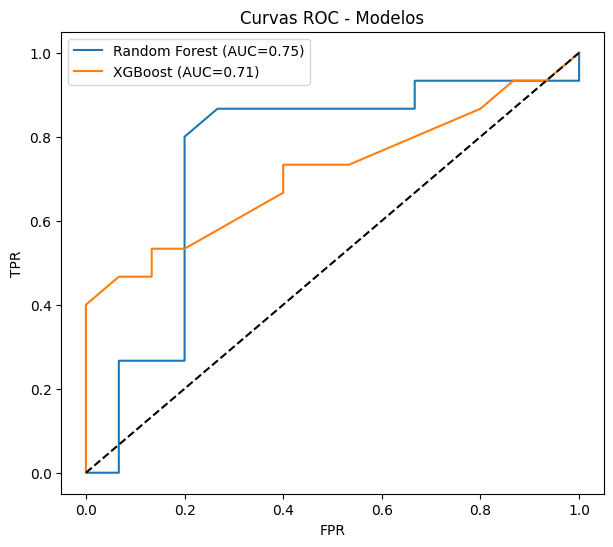

In [ ]:
plt.figure(figsize=(7,6))

def plot_roc(y_true, y_proba, label):
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{label} (AUC={roc_auc:.2f})")

#y_proba_log = clf.predict_proba(X_test_s)[:,1]
#plot_roc(y_test, y_proba_log, "Logistic")

y_proba_rf = rf.predict_proba(X_test)[:,1]
plot_roc(y_test, y_proba_rf, "Random Forest")

y_proba_xgb = xgb_best.predict_proba(X_test)[:,1]
plot_roc(y_test, y_proba_xgb, "XGBoost")

#y_proba_lgb = lgb_best.predict_proba(X_test)[:,1]
#plot_roc(y_test, y_proba_lgb, "LightGBM")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("Curvas ROC - Modelos")
plt.legend()
plt.savefig('roc_curves.png') # Save the plot
plt.show()